Task 1 - Data Loading & Exploration

In [31]:
import kagglehub

path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\pkuma\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


In [32]:
import pandas as pd
data = pd.read_csv(path + "/housing.csv")

In [33]:
data = pd.read_csv("D:\Project 1\Housing.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\pkuma\AppData\Local\Temp\ipykernel_24380\3624519260.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_csv("D:\Project 1\Housing.csv")


In [34]:
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [36]:
rows = pd.DataFrame(data).shape[0]
rows

545

In [37]:
columns = pd.DataFrame(data).shape[1]
columns

13

In [38]:
target = data['price']

Task 2 — Data Cleaning


In [39]:
data.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [40]:
data.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [41]:
data.duplicated().sum()

np.int64(0)

In [42]:
binary_columns = data.select_dtypes(include=['object']).columns.tolist()


In [43]:
binary_columns

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [44]:
for i in binary_columns:
    data[i] = data[i].astype('category').cat.codes
    

In [45]:
data.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad             int8
guestroom            int8
basement             int8
hotwaterheating      int8
airconditioning      int8
parking             int64
prefarea             int8
furnishingstatus     int8
dtype: object

In [46]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,2
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,2
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0


In [47]:

from sklearn.preprocessing import StandardScaler as Scaler
from sklearn.model_selection import train_test_split as TTS
data = pd.get_dummies(data ,columns = ['furnishingstatus'], drop_first=True)
matrix = data.corr().abs()
matrix



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_1,furnishingstatus_2
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.063656,0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,0.009229,0.222393,0.352980,0.234779,0.006156,0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.050040,0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.029834,0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,0.172394,0.018847,0.293602,0.045547,0.044425,0.003648,0.082972
mainroad,0.296898,0.288874,0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,0.011781,0.105423,0.204433,0.199876,0.011450,0.133123
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,0.010308,0.138179,0.037466,0.160897,0.005821,0.099023
basement,0.187057,0.047417,0.097312,0.102106,0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.050284,0.117935
hotwaterheating,0.093073,0.009229,0.046049,0.067159,0.018847,0.011781,0.010308,0.004385,1.000000,0.130023,0.067864,0.059411,0.063819,0.059194
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,0.130023,1.000000,0.159173,0.117382,0.053179,0.094086


Task 3 — Model Building

In [48]:
df = data[['price','area', 'airconditioning','bathrooms','prefarea','parking']]
df

,price,area,airconditioning,bathrooms,prefarea,parking
0,13300000,7420,1,2,1,2
1,12250000,8960,1,4,0,3
2,12250000,9960,0,2,1,2
3,12215000,7500,1,2,1,3
4,11410000,7420,1,1,0,2
...,...,...,...,...,...,...
540,1820000,3000,0,1,0,2
541,1767150,2400,0,1,0,0
542,1750000,3620,0,1,0,0
543,1750000,2910,0,1,0,0


In [49]:
X_train, X_test, y_train, y_test = TTS(df.drop('price', axis=1), df['price'], test_size=0.2, random_state=42)

In [50]:
X_train.head(5)

,area,airconditioning,bathrooms,prefarea,parking
46,6000,1,2,0,1
93,7200,1,2,0,3
335,3816,1,1,0,2
412,2610,0,1,1,0
471,3750,0,1,0,0


In [51]:
X_train_scaled = Scaler().fit_transform(X_train)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = Scaler().fit_transform(X_test)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [52]:
X_train.head(5)

,area,airconditioning,bathrooms,prefarea,parking
0,0.384168,1.501243,1.539173,-0.552620,0.367957
1,0.929181,1.501243,1.539173,-0.552620,2.709987
2,-0.607755,1.501243,-0.557950,-0.552620,1.538972
3,-1.155492,-0.666115,-0.557950,1.809561,-0.803059
4,-0.637730,-0.666115,-0.557950,-0.552620,-0.803059


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score 
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
lr.coef_

array([552052.54548485, 491258.76298738, 674740.70891348, 340167.28423076,
       220630.11851991])

In [55]:
prediction = lr.predict(X_test)
r2_score(y_test, prediction)



0.5400632814691368

In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rf)}")
print(f"Linear Regression R2 Score: {r2_score(y_test, prediction)}")

Random Forest R2 Score: 0.5056219987411388
Linear Regression R2 Score: 0.5400632814691368


In [57]:
print(f"Random Forest Mean Squared Error: {mean_squared_error(y_test, y_pred_rf)}")
print(f"Linear Regression Mean Squared Error: {mean_squared_error(y_test, prediction)}")

Random Forest Mean Squared Error: 2498868335617.835
Linear Regression Mean Squared Error: 2324782452694.4326


Task 4 — Visualization 

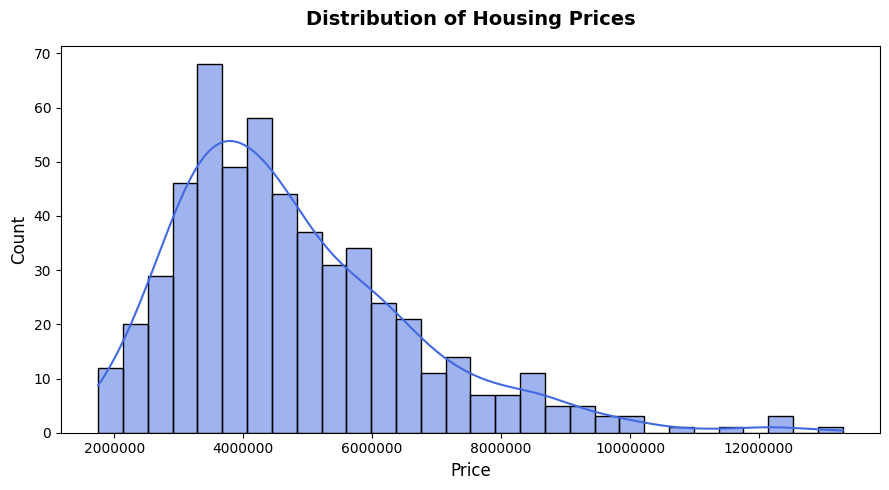

In [58]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(9, 5))
sns.histplot(df['price'], kde=True, color='royalblue', bins=30)

plt.title('Distribution of Housing Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') 
plt.tight_layout()
plt.savefig('housing_prices_distribution.png', dpi=300)
plt.show()


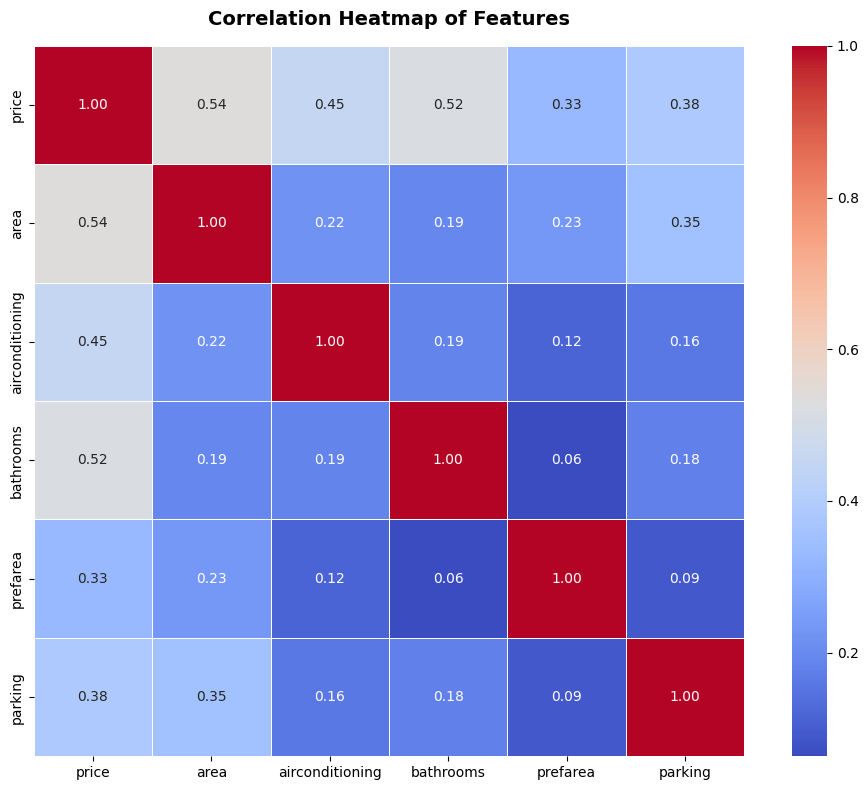

In [59]:
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()


plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

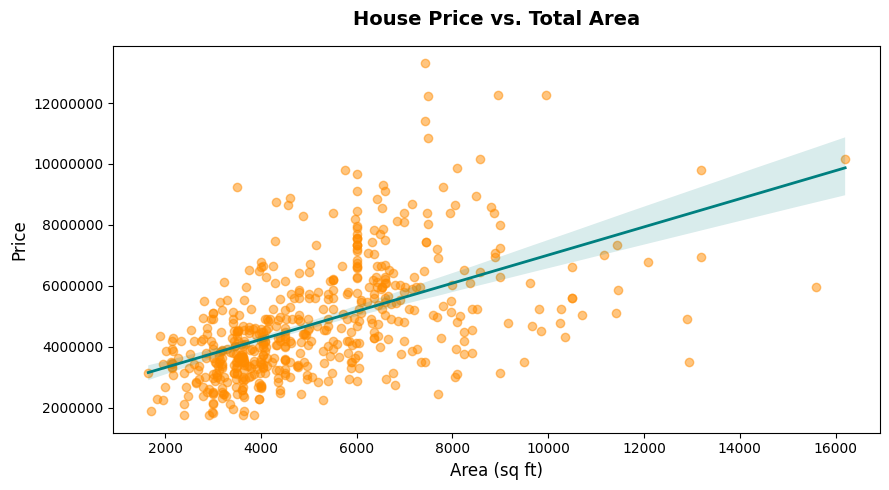

In [60]:
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x='area', y='price', 
            scatter_kws={'alpha':0.5, 'color': 'darkorange'}, 
            line_kws={'color': 'teal', 'linewidth': 2})
plt.title('House Price vs. Total Area', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Area (sq ft)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

# Save the plot before showing it
plt.savefig('price_vs_area.png', dpi=300)
plt.show()

Task 5 — Insights & Summary


Based on our exploratory data analysis and correlation heatmap, total property area and the availability of air conditioning emerged as the most significant drivers of housing prices. Our baseline Linear Regression model achieved a modest R2 score of 0.54, which in plain terms means it successfully captured about 54% of the factors dictating market value, while a more complex Random Forest model slightly underperformed at 0.50 due to the dataset's smaller sample scale. Surprisingly, the data revealed that structural features like the number of bedrooms had a much weaker direct correlation with price than the sheer physical footprint of the lot itself. For a real estate business looking to maximize returns, the clear recommendation is to prioritize marketing the total square footage and investing in modern climate control renovations, as these characteristics hold far more premium leverage in driving up property values than simply adding more rooms.